# Video 19: Ensemble and Model Selection
### Contiuation of Videos 17 & 18

# Import Required Libraries

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score , recall_score , precision_score, confusion_matrix

## Load the dataset

In [3]:
data = pd.read_csv('UCI Heart Disease Dataset.csv')
data.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,1,145,233,1,2,150,0,2.3,3,0,1,0
1,67,1,4,160,286,0,2,108,1,1.5,2,3,0,1
2,67,1,4,120,229,0,2,129,1,2.6,2,2,2,1
3,37,1,3,130,250,0,0,187,0,3.5,3,0,0,0
4,41,0,2,130,204,0,2,172,0,1.4,1,0,0,0


In [4]:
data.shape

(297, 14)

In [5]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 297 entries, 0 to 296
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       297 non-null    int64  
 1   sex       297 non-null    int64  
 2   cp        297 non-null    int64  
 3   trestbps  297 non-null    int64  
 4   chol      297 non-null    int64  
 5   fbs       297 non-null    int64  
 6   restecg   297 non-null    int64  
 7   thalach   297 non-null    int64  
 8   exang     297 non-null    int64  
 9   oldpeak   297 non-null    float64
 10  slope     297 non-null    int64  
 11  ca        297 non-null    int64  
 12  thal      297 non-null    int64  
 13  target    297 non-null    int64  
dtypes: float64(1), int64(13)
memory usage: 32.6 KB


In [6]:
data.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000
mean,54.542088,0.676768,3.158249,131.693603,247.350168,0.144781,0.996633,149.599327,0.326599,1.055556,1.602694,0.676768,0.835017,0.461279
std,9.049736,0.468500,0.964859,17.762806,51.997583,0.352474,0.994914,22.941562,0.469761,1.166123,0.618187,0.938965,0.956690,0.499340
min,29.000000,0.000000,1.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000
25%,48.000000,0.000000,3.000000,120.000000,211.000000,0.000000,0.000000,133.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000
50%,56.000000,1.000000,3.000000,130.000000,243.000000,0.000000,1.000000,153.000000,0.000000,0.800000,2.000000,0.000000,0.000000,0.000000
75%,61.000000,1.000000,4.000000,140.000000,276.000000,0.000000,2.000000,166.000000,1.000000,1.600000,2.000000,1.000000,2.000000,1.000000
max,77.000000,1.000000,4.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,3.000000,3.000000,2.000000,1.000000


In [7]:
x = data.drop('target', axis=1)
y = data['target']
x, y

(     age  sex  cp  trestbps  chol  fbs  restecg  thalach  exang  oldpeak  \
 0     63    1   1       145   233    1        2      150      0      2.3   
 1     67    1   4       160   286    0        2      108      1      1.5   
 2     67    1   4       120   229    0        2      129      1      2.6   
 3     37    1   3       130   250    0        0      187      0      3.5   
 4     41    0   2       130   204    0        2      172      0      1.4   
 ..   ...  ...  ..       ...   ...  ...      ...      ...    ...      ...   
 292   57    0   4       140   241    0        0      123      1      0.2   
 293   45    1   1       110   264    0        0      132      0      1.2   
 294   68    1   4       144   193    1        0      141      0      3.4   
 295   57    1   4       130   131    0        0      115      1      1.2   
 296   57    0   2       130   236    0        2      174      0      0.0   
 
      slope  ca  thal  
 0        3   0     1  
 1        2   3     0  
 2

Text(0, 0.5, 'Count')

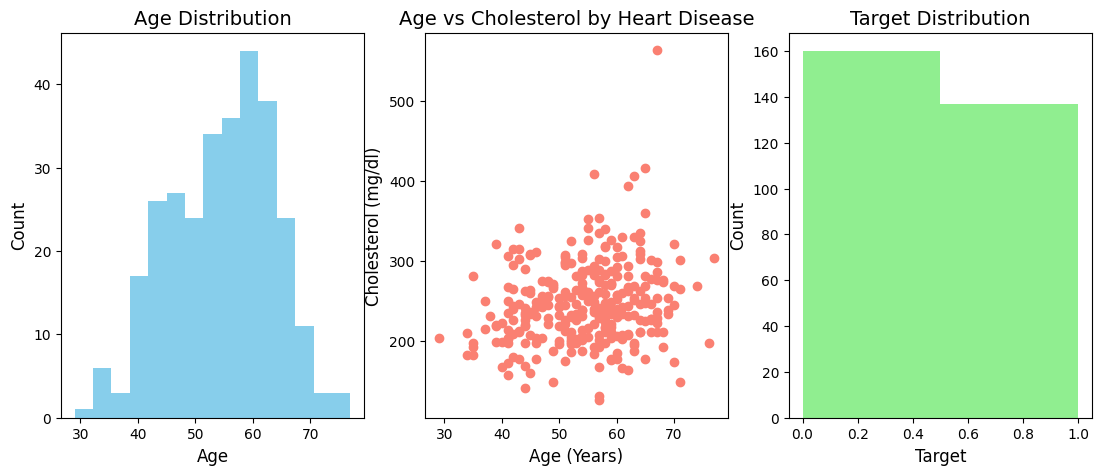

In [8]:
plt.figure(figsize=(18,5))

# histogram (AGE)
plt.subplot(1,4,1)
plt.hist(data['age'], bins=15 , color='skyblue')
plt.title('Age Distribution', fontsize=14)
plt.xlabel('Age',fontsize=12)
plt.ylabel('Count', fontsize=12)

# scatter plot (Chol)
plt.subplot(1,4,2)
plt.scatter(data['age'], data['chol'] , color='salmon')
plt.title('Age vs Cholesterol by Heart Disease', fontsize=14)
plt.xlabel('Age (Years)', fontsize=12)
plt.ylabel('Cholesterol (mg/dl)', fontsize=12)

# histogram
plt.subplot(1,4,3)
plt.hist(data['target'], bins=2 , color='lightgreen')
plt.title('Target Distribution', fontsize=14)
plt.xlabel('Target', fontsize=12)
plt.ylabel('Count', fontsize=12)

## Train-Test Split

In [9]:
x_train,x_test,y_train,y_test = train_test_split(x,y, test_size=0.2 , random_state=42)

## StandardScaler

In [10]:
scaler = StandardScaler()
x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)

x_train.shape, x_test.shape , y_train.shape , y_test.shape

((237, 13), (60, 13), (237,), (60,))

## Training Model
- Train Support Vector Machine Model

In [11]:
class SupportVectorMachineModel(SVC):
    def __init__(self):
        super().__init__(
            kernel='linear'
        )

    def fit_model(self,x,y):
        super().fit(x,y)
        print('Model Tranined.')

    def predict_model(self,x):
        return super().predict(x)

In [12]:
model = SupportVectorMachineModel()
model.fit_model(x_train,y_train)

Model Tranined.


In [13]:
pred_train = model.predict_model(x_train)
pred_test = model.predict_model(x_test)

## Model Evaluation

### Accuracy

In [14]:
ac_train = accuracy_score(y_train, pred_train)
ac_test = accuracy_score(y_test, pred_test)
ac_train * 100 , ac_test * 100

(83.96624472573839, 86.66666666666667)

### Precision

In [15]:
p_train = precision_score(y_train,pred_train)
p_test  =  precision_score(y_test, pred_test)
p_train * 100 , p_test * 100

(85.71428571428571, 86.36363636363636)

### Recall

In [16]:
recall_train = recall_score(y_train , pred_train )
recall_test = recall_score(y_test, pred_test)
recall_train * 100 , recall_test * 100

(79.64601769911505, 79.16666666666666)

### Confusion_matrix

In [17]:
con_train = confusion_matrix(y_train , pred_train)
con_test = confusion_matrix(y_test, pred_test)
print('confusion_train: ', con_train)
print('confusion_test: ', con_test)

confusion_train:  [[109  15]
 [ 23  90]]
confusion_test:  [[33  3]
 [ 5 19]]


## Neural Network Model - Custom Implementation
- In this section, we define a custom NeuralNetwork model using a
- class-based design. 

In [18]:
from sklearn.neural_network import MLPClassifier

class NeuralNetworkModel(MLPClassifier):
    def __init__(self):
        super().__init__(
            hidden_layer_sizes = 350 ,
            max_iter = 1000 , 
            activation = 'relu'
        ) 
    def fit_nn_model(self,x,y):
        super().fit(x,y)
        print('Model Trained.')
    def predict_nn_model(self,x):
        return super().predict(x)

## Train Neural Network Model

In [19]:
nn_model = NeuralNetworkModel()
nn_model.fit_nn_model(x_train,y_train)

Model Trained.


In [20]:
pred_nn = nn_model.predict_nn_model(x_test)

## Evaluation Neural Network Model
- we evaluated the Neural Network on the test set using:
   - Accuracy, Precision, Recall, and Confusion Matrix.    

In [21]:
ac_nn = accuracy_score(y_test , pred_nn)
p_nn = precision_score(y_test, pred_nn)
recall_nn = recall_score(y_test, pred_nn)
con_nn = confusion_matrix(y_test, pred_nn)
print('Accuracy Test: ', ac_nn * 100)
print('Precision Test: ', p_nn * 100)
print('Recall Test:‌ ', recall_nn * 100)
print('Confusion Matrix: ', con_nn)

Accuracy Test:  88.33333333333333
Precision Test:  84.0
Recall Test:‌  87.5
Confusion Matrix:  [[32  4]
 [ 3 21]]


## XGBoost Model - Custom Implementation
- In this section, we define a custom XGBoost model
- using a class-based design. 

## Train XGBoost Model

In [22]:
from xgboost import XGBClassifier

class GradientBoostingModel(XGBClassifier):
    def __init__(self):
        super().__init__()

    def fit_xgb_model(self, x,y):
        super().fit(x,y)
        print('Model Trained.')
    def predict_xgb_model(self,x):
        return super().predict(x)

xgb_model = GradientBoostingModel()

In [23]:
xgb_model.fit_xgb_model(x_train,y_train)

Model Trained.


In [24]:
pred_xgb = xgb_model.predict_xgb_model(x_test)

## Evaluation XGBoost Model
- The XGBoost model is evaluated using the same metrics
- to ensure a fair comparsion with other models.

In [25]:
ac_xgb = accuracy_score(y_test, pred_xgb)
p_xgb = precision_score(y_test, pred_xgb)
recall_xgb = recall_score(y_test, pred_xgb)
con_xgb = confusion_matrix(y_test, pred_xgb)
print('Accuracy Test: ', ac_xgb * 100)
print('Precision Test: ', p_xgb * 100)
print('Recall Test: ', recall_xgb * 100)
print('Confusion Matrix: ', con_xgb)

Accuracy Test:  83.33333333333334
Precision Test:  75.0
Recall Test:  87.5
Confusion Matrix:  [[29  7]
 [ 3 21]]


## Ensemble Model - Custom Implementation
- In this section, we define a custom Ensemble model
- using a class-based design. 

In [26]:
from sklearn.ensemble import StackingClassifier

base_model = [('NeuralNetwork', MLPClassifier(hidden_layer_sizes=300 , max_iter=1000, activation='relu')),(
              'SVM', SVC(kernel='linear')),
              ('xgbost', XGBClassifier())]

ensemble_model = StackingClassifier(estimators=base_model,final_estimator=MLPClassifier())
ensemble_model.fit(x_train,y_train)

,estimators,"[('NeuralNetwork', ...), ('SVM', ...), ...]"
,final_estimator,MLPClassifier()
,cv,None
,stack_method,'auto'
,n_jobs,None
,passthrough,False
,verbose,0
,hidden_layer_sizes,300
,activation,'relu'
,solver,'adam'
,alpha,0.0001


In [27]:
pred_ensemble = ensemble_model.predict(x_test)

## Evaluation Ensemble Model
- The ensemble model is evaluated to measure whether
- combining multiple models improves overall performance.

In [28]:
ac_ensemble = accuracy_score(y_test, pred_ensemble)
p_ensemble = precision_score(y_test, pred_ensemble)
recall_ensemble = recall_score(y_test, pred_ensemble)
con_ensemble = confusion_matrix(y_test, pred_ensemble)
print('Accuracy Test: ', ac_ensemble * 100)
print('Precision Test: ', p_ensemble * 100)
print('Recall Test: ', recall_ensemble * 100)
print('Confusion Matrix: ', con_ensemble)

Accuracy Test:  86.66666666666667
Precision Test:  86.36363636363636
Recall Test:  79.16666666666666
Confusion Matrix:  [[33  3]
 [ 5 19]]


# Model Performance Comparsion
- Comparing Accuracy, Precision and Recall for all models

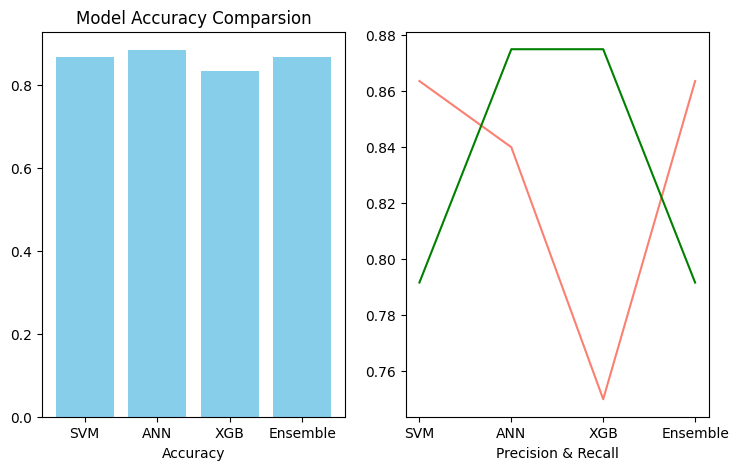

In [34]:
model_names = ['SVM', 'ANN', 'XGB', 'Ensemble']
accuracy_values = [ac_test , ac_nn, ac_xgb, ac_ensemble]

plt.figure(figsize=(18,5))
plt.subplot(1,4,1)
# bar chart
plt.bar(model_names , accuracy_values , color='skyblue')
plt.title('Model Accuracy Comparsion')
plt.xlabel('Accuracy')

precision_values = [p_test, p_nn , p_xgb, p_ensemble]
recall_values = [recall_test, recall_nn, recall_xgb , recall_ensemble]
plt.subplot(1,4,2)
plt.plot(model_names , precision_values , color='salmon')
plt.plot(model_names , recall_values , color='green')
plt.xlabel('Precision & Recall')
plt.show()